# Generative Models

<figure>
    <img src="https://drive.google.com/uc?export=view&id=1UjunyOkHxHewQ51X75Edq8VYlQshNyRr" alt="Picture" style="display: block; margin: 0 auto;" />
    <figcaption style="text-align: center;"><strong>Fig. 1: Face Generation using GAN. Source: <a href="https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf">https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf</a></strong></figcaption>
</figure>



In [ ]:
#@title Imports

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

import tensorflow as tf

from torch.utils.data import DataLoader

In [ ]:
#@title Auxiliary Functions

class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view(x.size(0), *self.shape)


def generate_noise(batch_size, noise_dim):
    return torch.randn(batch_size, noise_dim, 1, 1).to(device)

def generate_images(generator):
    noise = generate_noise(25, 100)

    generator.eval()
    generated_images = generator(noise)
    generated_images = generated_images.view(25, 28, 28).detach().cpu().numpy()

    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

In [ ]:
#@title Dataset

transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = datasets.MNIST(root='MNIST_data/', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='MNIST_data/', train=False, download=True, transform=transform)

#trainset = Subset(trainset, range(0, len(trainset)//10))
#testset = Subset(testset, range(0, len(testset)//10))

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=True)

# Variational Auto-Encoders

> #### **Exercise:** Using the MNIST dataset train a variational autoencoder. To do this you must implement the encoder, the decoder, the reparametrize trick, and the loss function. Then, show the generated latent space. Finally, analyze the obtained results.

### Encoder

|Layer (Type)| Output Shape |
|-|-|
| Input Layer | (28, 28, 1) |
| Conv2D | (28, 28, 32) |
| Conv2D | (14, 14, 32) |
| Conv2D | (14, 14, 64) |
| Flatten | 14x14x64 |
| Dense $(z \ \mu)$  | Latent Dim |
| Dense $(z \ log \ var)$ | Latent Dim |
| Sampling($z$) | Latent Dim |

Activation Functions: ReLU


In [ ]:
# To-Do
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.latent_dim = 5
        # Convolutional Layers
        self.conv1 =
        self.conv2 =
        self.conv3 =

        self.fc1 =
        self.fc2 =

        self.Flatten = nn.Flatten()

        self.encoder = nn.Sequential(

        )

    # Reparametrization Trick (Sampling)
    def sampling(self, mu, log_var):
        std =

        # eps ->  mean = 0 and std = 1.0
        eps =
        return mu + eps*std

    def forward(self, x):
        x = self.encoder(x)
        x = self.Flatten(x)
        mu = self.fc1(x)
        log_var = self.fc2(x)
        z = self.sampling(mu, log_var)
        return z, mu, log_var

### Decoder

| Layer (Type)                | Output Shape |
|-----------------------------|--------------|
| Dense        | (Latent Dim, 14x14x64)    |
| Reshape                     | (64, 14, 14)   |
| ConvTranspose2D | (32, 28, 28) |
| ConvTranspose2D | (28, 28, 1) |
| ConvTranspose2D | (28, 28, 1)  |

Activation Functions:
- ReLU and Sigmoid for the output layer

In [ ]:
# To-Do
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.latent_dim = 5

        # Fully Connected Layer
        self.fc = nn.Linear( , )
        # Convolutional Transpose Layers
        self.conv2d_transpose1 = nn.ConvTranspose2d( output_padding=1)
        self.conv2d_transpose2 =
        self.conv2d_transpose3 =

        self.decoder = nn.Sequential(
            self.fc,
            .
            .
            .
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

### VAE Model

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, mu, log_var = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def loss(self, x, x_hat, mu, log_var):
        # To-Do
        KL =
        recostruction = F.mse_loss(, reduction='sum')
        return KL + recostruction

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train(model, trainloader, optimizer, epochs=5):
    model.train()
    for epoch in range(epochs):
        for i, (x, _) in enumerate(trainloader):
            x = x.to(device)
            x_hat, mu, log_var = model(x)
            loss = model.loss(x, x_hat, mu, log_var)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if i % 100 == 0:
                print(f'\rEpoch {epoch}, Iteration {i}, Loss: {loss.item():.4f}', end="")

train(model, trainloader, optimizer, epochs=5)

Epoch 4, Iteration 1800, Loss: 3349.0938

### Latent Space

In [ ]:
# Plot latent space with labels
import numpy as np
from sklearn.manifold import TSNE
from sklearn.manifold import MDS

model.eval()
z = []
labels = []
with torch.no_grad():
    for x, y in testloader:
        x = x.to(device)
        z_, _, _ = model.encoder(x)
        z.append(z_.cpu().numpy())
        labels.append(y.numpy())

In [ ]:
# MDS
z = np.concatenate(z)
#mds = MDS(n_components=2)
tsne = TSNE(n_components=2)
z = tsne.fit_transform(z)

labels = np.concatenate(labels)
plt.figure(figsize=(10, 10))
plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10')
plt.colorbar()
plt.show()

### Latent Space (Numbers)

In [ ]:
from scipy.stats import norm
n = 20  # figure with 20x20 digits
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Construct grid of latent variable values
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # with 5 latent vaariables, we can only visualize 2 dimensions
            # so we fix the other dimensions to 1
            z_sample = np.array([[xi, yi, 1, 1, 1]])
            z_sample = np.tile(z_sample, 32).reshape(32, 5)
            z_sample = torch.tensor(z_sample, dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)
            x_decoded = x_decoded.cpu().numpy()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.show()

### Reconstructions

In [ ]:

# Grid with numbers sampled from the latent space
import numpy as np
def plot_images(rows, cols, images, title):
    '''Displays images in a grid.'''
    images = images.reshape(rows, cols, 28, 28)  # Reshape images array
    grid = np.zeros(shape=(rows*28, cols*28))
    for i in range(rows):
        for j in range(cols):
            grid[i*28:(i+1)*28, j*28:(j+1)*28] = images[i, j]


    plt.figure(figsize=(12,12))
    plt.imshow(grid, cmap='gray')
    plt.title(title)
    plt.show()

model.eval()
n = 10
# Use normal distribution to sample from latent space
latent_space = torch.randn(n*n, model.encoder.latent_dim).to(device)
images = model.decoder(latent_space).view(-1, 1, 28, 28).cpu().detach().numpy()
plot_images(n, n, images, 'Latent Space')

> ### **Exercise:**  Adapt the loss function to use the hyperparameter $\beta$. Then, check how the modification of this parameter influences the generation of the latent space.

https://openreview.net/pdf?id=Sy2fzU9gl

# Generative Adversarial Networks

> ### **Exercise:** Implement the Generator and the Discriminator. Then generate some samples and plot the loss of the generator and discriminator.

### Generator

---
   |Layer (type)     |          Output Shape |
   |--|--|
   |ConvTranspose2d      |     [128, 7, 7]    |
   |ConvTranspose2d      |     [128, 7, 7]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |           Tanh      |         |
   
   ---


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.conv2d_transpose1 =
        self.conv2d_transpose2 =
        self.conv2d_transpose3 =

        self.generator = nn.Sequential(

        )


    def forward(self, x):
        return self.generator(x)

### Discriminator

---
| Layer (type)      |         Output Shape  |
|--|--|
|      Conv2d        |   [64, 14, 14]   |
|      Conv2d        |   [64, 14, 14]   |
|   ReLU        |      |
|      Conv2d        |   [128, 7, 7]   |
|      Conv2d        |   [128, 7, 7]   |
|   ReLU        |      |
|      Conv2d        |   [1, 1, 1]   |
|     Sigmoid        |      |
---

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv2d1 =
        self.conv2d2 =
        self.conv2d3 =

        self.discriminator = nn.Sequential(







        )

    def forward(self, x):
        return self.discriminator(x)

### Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.00005)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.00005)

loss_generator_iters = []
loss_discriminator_iters = []

def train():
    # Real and Fake labels
    real_label, fake_label = 1, 0

    # Loss function
    criterion = nn.BCELoss()

    for epoch in range(5):

        for i, (real_images, _) in enumerate(trainloader):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)
            real_labels = torch.full((batch_size, 1,1,1), real_label, dtype=torch.float, device=device)
            fake_labels = torch.full((batch_size, 1,1,1), fake_label, dtype=torch.float, device=device)

            # Train the discriminator
            discriminator.zero_grad()
            output = discriminator(real_images)
            loss_real = criterion(output, real_labels)
            loss_real.backward()


            # Generate fake images
            noise = generate_noise(batch_size, 100)
            fake_images = generator(noise)
            output = discriminator(fake_images.detach())
            loss_fake = criterion(output, fake_labels)
            loss_fake.backward()


            discriminator_optimizer.step()

            # Train the generator
            generator.zero_grad()
            output = discriminator(fake_images)
            loss_generator = criterion(output, real_labels)
            loss_generator.backward()

            generator_optimizer.step()

            print(f'\rEpoch [{epoch}], Step [{i}/{len(trainloader)}], Loss D: {loss_real + loss_fake}, Loss G: {loss_generator}', end='')

        # Save images for plot on each epoch
        generate_images(generator)

        # Save losses
        loss_generator_iters.append(loss_generator.item())
        loss_discriminator_iters.append(loss_real.item() + loss_fake.item())

In [ ]:
%matplotlib inline
train()

> ### **Exercise:** Improve the Generator and the Discriminator (you can add some Batch Normalization layers, dropout, etc). Then, generate new samples and compare the results.

# Diffusion Networks

Reference: [Colab](https://colab.research.google.com/github/st-howard/blog-notebooks/blob/main/MNIST-Diffusion/Diffusion%20Digits%20-%20Generating%20MNIST%20Digits%20from%20noise%20with%20HuggingFace%20Diffusers.ipynb#scrollTo=a1a0807f)

In [ ]:
%%capture
!pip install diffusers[training]==0.2.3

In [ ]:
# Imports

# Pytorch
import torch
import torchvision

# HuggingFace
import datasets
import diffusers
import accelerate

# Training and Visualization
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
import PIL
from torch.utils.data import DataLoader, Subset

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size=32 #Resize the digits to be a power of two
    train_batch_size = 32
    eval_batch_size = 32
    num_epochs = 5
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmpup_steps = 500
    mixed_precision = 'fp16'
    seed = 0

config = TrainingConfig()

mnist_dataset = datasets.load_dataset('mnist', split='train')

def transform(dataset):
    preprocess = torchvision.transforms.Compose(
        [
            torchvision.transforms.Resize(
                (config.image_size, config.image_size)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Lambda(lambda x: 2*(x-0.5)),
        ]
    )
    images = [preprocess(image) for image in dataset["image"]]
    return {"images": images}

mnist_dataset.reset_format()
mnist_dataset.set_transform(transform)

mnist_dataset = Subset(mnist_dataset, range(20000))

train_dataloader = torch.utils.data.DataLoader(
    mnist_dataset,
    batch_size = config.train_batch_size,
    shuffle = True,
)

In [ ]:
model = diffusers.UNet2DModel(
    sample_size=config.image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(128,128,256,512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)


In [ ]:
noise_scheduler = diffusers.DDPMScheduler(num_train_timesteps=200, tensor_format='pt')

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(),lr=config.learning_rate)

In [ ]:
# Cosine learning rate scheduler

lr_scheduler = diffusers.optimization.get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmpup_steps,
    num_training_steps=(len(train_dataloader)*config.num_epochs),
)

In [ ]:
def train_loop(
        config,
        model,
        noise_scheduler,
        optimizer,
        train_dataloader,
        lr_scheduler):

    accelerator = accelerate.Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader),
                            disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images = batch['images']

            noise = torch.randn(clean_images.shape).to(clean_images.device)
            batch_size = clean_images.shape[0]

            # Sample a set of random time steps for each image in mini-batch
            timesteps = torch.randint(
                0, noise_scheduler.num_train_timesteps, (batch_size,), device=clean_images.device)

            noisy_images=noise_scheduler.add_noise(clean_images, noise, timesteps.cpu())

            with accelerator.accumulate(model):
                noise_pred = model(noisy_images,timesteps)["sample"]
                loss = torch.nn.functional.mse_loss(noise_pred,noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(),1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {
                "loss" : loss.detach().item(),
                "lr" : lr_scheduler.get_last_lr()[0],
            }
            progress_bar.set_postfix(**logs)

    accelerator.unwrap_model(model)

In [ ]:
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

accelerate.notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

In [ ]:
@torch.no_grad()
def sample(unet, scheduler, seed, save_process_dir=None):
    torch.manual_seed(seed)

    if save_process_dir:
        if not os.path.exists(save_process_dir):
            os.mkdir(save_process_dir)

    scheduler.set_timesteps(1000)
    image = torch.randn((1, 1, 32, 32)).to(model.device)
    num_steps = max(noise_scheduler.timesteps).numpy()

    images = []
    for t in noise_scheduler.timesteps:
        model_output = unet(image, t)['sample']
        image = scheduler.step(model_output, int(t), image, generator=None)['prev_sample']

        if t % 10 == 0:
            save_image = torchvision.transforms.ToPILImage()(image.squeeze(0))
            images.append(save_image)


    return torchvision.transforms.ToPILImage()(image.squeeze(0)), images

def plot_images(images):
    fig, axs = plt.subplots(2, 10, figsize=(15, 6))
    for i in range(2):
        for j in range(10):
            axs[i, j].imshow(images[i * 10 + j], cmap='gray')
            axs[i, j].axis('off')
    plt.show()

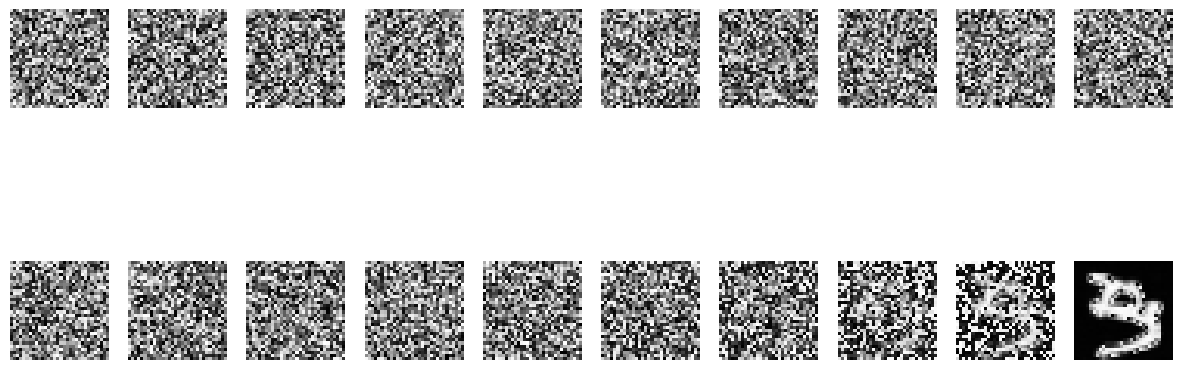

In [ ]:
test_image, images =sample(model,noise_scheduler,2)
plot_images(images)

> ### **Exercise:** Compare the results with the GAN model. Change the noise used in the Diffusion Networks and generate new samples.

[Schedulers](https://huggingface.co/docs/diffusers/v0.3.0/en/api/schedulers#diffusers.DDPMScheduler)